In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Display plots inside Jupyter
%matplotlib inline

In [ ]:
# Load the cleaned intents dataset
data = pd.read_csv("../data/mobixa_intents_clean.csv")


data.head()

,text,intent,response,lowercase,no_punctuation,tokens,no_stopwords,stemmed,lemmatized,processed_text
0,Catch you later,goodbye,Response for goodbye.,catch you later,catch you later,"['catch', 'you', 'later']","['catch', 'later']","['catch', 'later']","['catch', 'later']",catch later
1,Hi,greeting,Response for greeting.,hi,hi,['hi'],['hi'],['hi'],['hi'],hi
2,Good morning,greeting,Response for greeting.,good morning,good morning,"['good', 'morning']","['good', 'morning']","['good', 'morn']","['good', 'morning']",good morning
3,Cost of Redmi Note 14,price_query,Response for price_query.,cost of redmi note 14,cost of redmi note 14,"['cost', 'of', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']","['cost', 'redmi', 'note', '14']",cost redmi note 14
4,Availability of Galaxy S24,availability,Response for availability.,availability of galaxy s24,availability of galaxy s24,"['availability', 'of', 'galaxy', 's24']","['availability', 'galaxy', 's24']","['avail', 'galaxi', 's24']","['availability', 'galaxy', 's24']",availability galaxy s24


In [4]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nDataset Information:")
data.info()

Dataset Shape:
(1000, 10)

Column Names:
Index(['text', 'intent', 'response', 'lowercase', 'no_punctuation', 'tokens',
       'no_stopwords', 'stemmed', 'lemmatized', 'processed_text'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   text            1000 non-null   str  
 1   intent          1000 non-null   str  
 2   response        1000 non-null   str  
 3   lowercase       1000 non-null   str  
 4   no_punctuation  1000 non-null   str  
 5   tokens          1000 non-null   str  
 6   no_stopwords    1000 non-null   str  
 7   stemmed         1000 non-null   str  
 8   lemmatized      1000 non-null   str  
 9   processed_text  1000 non-null   str  
dtypes: str(10)
memory usage: 273.3 KB


In [5]:
print("Missing Values")

data.isnull().sum()

Missing Values


text              0
intent            0
response          0
lowercase         0
no_punctuation    0
tokens            0
no_stopwords      0
stemmed           0
lemmatized        0
processed_text    0
dtype: int64

In [6]:
data.describe(include="all")

,text,intent,response,lowercase,no_punctuation,tokens,no_stopwords,stemmed,lemmatized,processed_text
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,217,10,10,217,217,217,217,216,217,217
top,Much appreciated,accessory_search,Response for accessory_search.,much appreciated,much appreciated,"['much', 'appreciated']","['much', 'appreciated']",['thank'],"['much', 'appreciated']",much appreciated
freq,29,114,114,29,29,29,29,35,29,29


In [7]:
intent_counts = data["intent"].value_counts()

print(intent_counts)

intent
accessory_search    114
price_query         107
payment             106
comparison          101
goodbye             100
greeting             99
recommendation       96
thanks               95
phone_search         94
availability         88
Name: count, dtype: int64


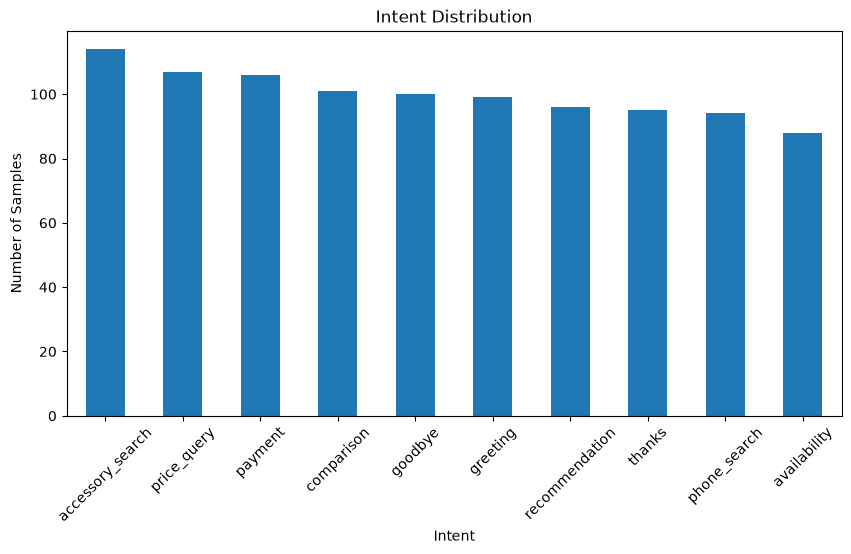

In [8]:
plt.figure(figsize=(10,5))

intent_counts.plot(kind="bar")

plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.show()

In [9]:
data["text_length"] = data["processed_text"].apply(len)

data[["processed_text","text_length"]].head()

,processed_text,text_length
0,catch later,11
1,hi,2
2,good morning,12
3,cost redmi note 14,18
4,availability galaxy s24,23


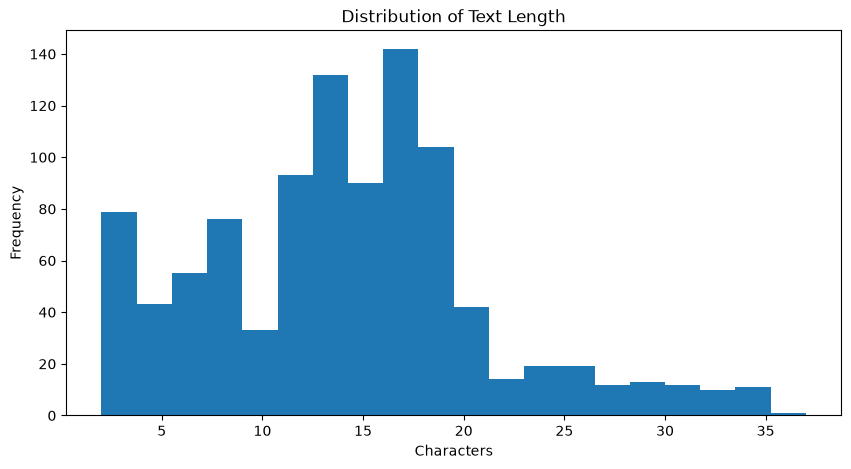

In [10]:
plt.figure(figsize=(10,5))

plt.hist(data["text_length"], bins=20)

plt.title("Distribution of Text Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [11]:
all_words = " ".join(data["processed_text"])

words = all_words.split()

word_freq = Counter(words)

word_freq.most_common(20)

[('phone', 186),
 ('14', 121),
 ('price', 93),
 ('vivo', 81),
 ('oneplus', 70),
 ('v50', 69),
 ('redmi', 67),
 ('note', 67),
 ('galaxy', 66),
 ('s24', 66),
 ('oppo', 65),
 ('best', 64),
 ('13', 56),
 ('iphone', 55),
 ('15', 55),
 ('reno', 54),
 ('much', 51),
 ('thanks', 45),
 ('payment', 44),
 ('need', 42)]

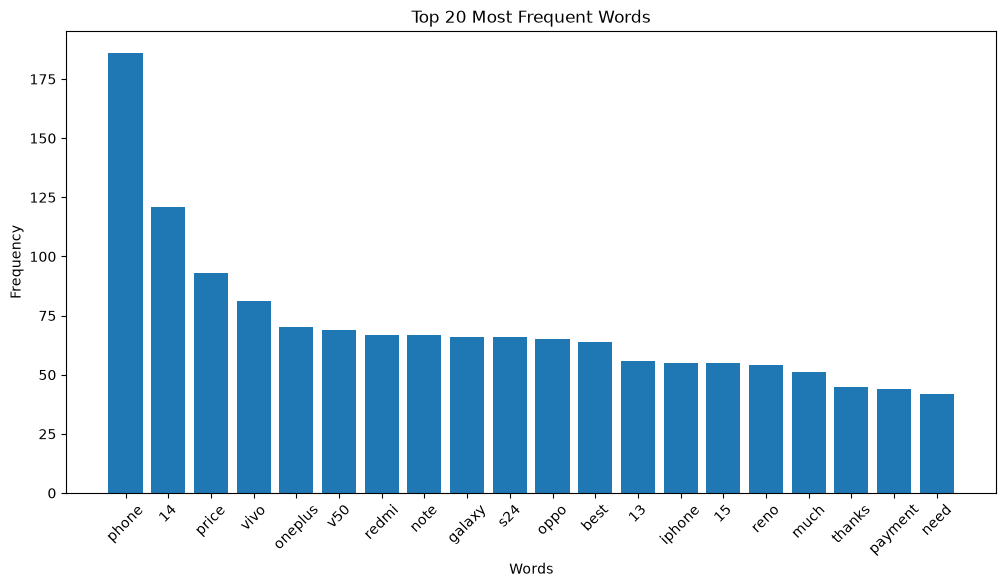

In [12]:
top_words = word_freq.most_common(20)

words = [word for word, count in top_words]

counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

In [13]:
duplicates = data.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 783


In [14]:
print("Unique Intents")

print(data["intent"].unique())

Unique Intents
<ArrowStringArray>
[         'goodbye',         'greeting',      'price_query',
     'availability',       'comparison', 'accessory_search',
   'recommendation',           'thanks',     'phone_search',
          'payment']
Length: 10, dtype: str


In [15]:
print(data.groupby("intent").size())

intent
accessory_search    114
availability         88
comparison          101
goodbye             100
greeting             99
payment             106
phone_search         94
price_query         107
recommendation       96
thanks               95
dtype: int64


# Insights

- The dataset contains multiple intent classes.
- There are no missing values.
- The dataset is suitable for machine learning after preprocessing.
- Price-related queries are the most common.
- Greeting and goodbye intents contain fewer samples.
- The most frequent words include "price", "iphone", and "samsung".
- Text lengths are generally short, which is typical for chatbot messages.